# Model Preparation and Baseline Model


## Introduction

The previous notebooks focused on understanding the dataset, exploratory analysis, statistical testing, and multivariate relationships.

The purpose of this notebook is to prepare the selected features for machine learning and establish a baseline churn prediction model.

The main steps will include:
- defining the target variable and predictor features,
- splitting the data into training and test sets,
- preprocessing numerical and categorical variables,
- building a preprocessing pipeline,
- training a baseline Logistic Regression model,
- evaluating its predictive performance.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from sklearn.metrics import ConfusionMatrixDisplay



df = pd.read_csv("../data/processed/telco_customer_churn_cleaned.csv")

In [4]:
selected_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Tenure Months",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

In [5]:
X = df[selected_features]

y = df["Churn Label"].map({
    "No": 0,
    "Yes": 1
})

X.shape

(7043, 20)

In [6]:
y.value_counts()

Churn Label
0    5174
1    1869
Name: count, dtype: int64

In [7]:
y.value_counts(normalize=True)

Churn Label
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Churn Label
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn Label
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## Preprocessing Pipeline

The dataset contains both numerical and categorical features, which require different preprocessing steps before model training. Numerical features will be scaled, while categorical features will be transformed using one-hot encoding.

In [9]:
numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

categorical_features = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

In [12]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Baseline Model Training

In [15]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['Gender','Senior Citizen','Partner',...,'Monthly Charges','Total Charges', 'CLTV']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthro

## Cross-Validation

In [19]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    model_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]
)

pd.DataFrame(cv_results)

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_average_precision
0,0.067215,0.039781,0.811003,0.666667,0.575251,0.617594,0.862759,0.660120
1,0.062155,0.035706,0.790594,0.623529,0.531773,0.574007,0.838188,0.653038
2,0.059370,0.035625,0.808341,0.664032,0.561873,0.608696,0.851667,0.702055
3,0.049258,0.038131,0.826974,0.678082,0.662207,0.670051,0.872748,0.696969
4,0.056603,0.036039,0.823268,0.701613,0.581940,0.636197,0.868716,0.687173


In [39]:
cv_summary = pd.DataFrame({
    "Mean": {
        "Accuracy": cv_results["test_accuracy"].mean(),
        "Precision": cv_results["test_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "F1": cv_results["test_f1"].mean(),
        "ROC-AUC": cv_results["test_roc_auc"].mean(),
        "PR-AUC": cv_results["test_average_precision"].mean()
    },
    "Std": {
        "Accuracy": cv_results["test_accuracy"].std(),
        "Precision": cv_results["test_precision"].std(),
        "Recall": cv_results["test_recall"].std(),
        "F1": cv_results["test_f1"].std(),
        "ROC-AUC": cv_results["test_roc_auc"].std(),
        "PR-AUC": cv_results["test_average_precision"].std()
    }
})

cv_summary

,Mean,Std
Accuracy,0.812036,0.012836
Precision,0.666785,0.025374
Recall,0.582609,0.043370
F1,0.621309,0.031647
ROC-AUC,0.858816,0.012524
PR-AUC,0.679871,0.019738


Logistic Regression provides a reasonably strong baseline model. The model achieves an average accuracy of approximately 81% and a ROC-AUC of approximately 0.86 across the five cross-validation folds. Precision is around 67%, indicating that roughly two thirds of customers predicted to churn actually churn. Recall is lower, at approximately 58%, meaning that the model fails to identify a substantial proportion of actual churn customers. The resulting F1-score of approximately 0.62 reflects this trade-off between precision and recall.

The default classification threshold of 0.50 is commonly used to convert predicted probabilities into class labels, but it is not necessarily the most suitable choice for a churn prediction problem. In this case, recall is relatively low at the default threshold, meaning that a substantial proportion of actual churn customers is not identified. Therefore, different probability thresholds are evaluated to examine the trade-off between precision and recall.

In [38]:
y_train_proba = cross_val_predict(
    model_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba"
)[:, 1]

In [ ]:
thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_train_proba >= threshold).astype(int)

    precision = precision_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_train,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Predicted Churn": y_pred_threshold.sum()
    })

threshold_table = pd.DataFrame(threshold_results)

threshold_table

,Threshold,Precision,Recall,F1,Predicted Churn
0,0.20,0.491564,0.876923,0.629986,2667
1,0.25,0.521480,0.820067,0.637546,2351
2,0.30,0.556193,0.777926,0.648634,2091
3,0.35,0.584360,0.729766,0.649018,1867
4,0.40,0.606655,0.682943,0.642542,1683
5,0.45,0.634963,0.634114,0.634538,1493
6,0.50,0.666922,0.582609,0.621921,1306
7,0.55,0.697880,0.528428,0.601447,1132
8,0.60,0.723799,0.443478,0.549979,916
9,0.65,0.758571,0.355184,0.483827,700


The threshold analysis shows a clear trade-off between precision and recall. Lower thresholds increase recall and allow the model to identify more actual churn customers, but they also increase the number of false positives and reduce precision. Higher thresholds have the opposite effect. 

In practice, the final threshold is usually selected according to business priorities, such as the cost of missing a churn customer, the cost of unnecessary retention actions, or the available capacity of a retention campaign.

For this analysis, a threshold of 0.35 was selected as a reasonable compromise between precision and recall. At this threshold, the model achieves approximately 58% precision and 73% recall, while also producing the highest F1-score among the evaluated thresholds. This threshold will therefore be used as an alternative to the default 0.50 threshold during final model evaluation.

After selecting the threshold using cross-validated predictions from the training data, the model is refitted on the full training set and evaluated once on the held-out test set. This provides an unbiased estimate of final model performance.

In [30]:
model_pipeline.fit(X_train, y_train)

y_test_proba = model_pipeline.predict_proba(X_test)[:, 1]

In [31]:
chosen_threshold = 0.35

y_test_pred_035 = (
    y_test_proba >= chosen_threshold
).astype(int)

In [34]:
test_results_035 = {
    "Accuracy": accuracy_score(y_test, y_test_pred_035),
    "Precision": precision_score(y_test, y_test_pred_035),
    "Recall": recall_score(y_test, y_test_pred_035),
    "F1": f1_score(y_test, y_test_pred_035),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba),
    "PR-AUC": average_precision_score(y_test, y_test_proba)
}

pd.Series(test_results_035)

Accuracy     0.775018
Precision    0.559499
Recall       0.716578
F1           0.628370
ROC-AUC      0.848942
PR-AUC       0.644167
dtype: float64

Let's compare the new threshold 0.35 with the default one.

In [35]:
y_test_pred_050 = (
    y_test_proba >= 0.50
).astype(int)

comparison = pd.DataFrame({
    "Threshold 0.50": {
        "Accuracy": accuracy_score(y_test, y_test_pred_050),
        "Precision": precision_score(y_test, y_test_pred_050),
        "Recall": recall_score(y_test, y_test_pred_050),
        "F1": f1_score(y_test, y_test_pred_050)
    },
    "Threshold 0.35": {
        "Accuracy": accuracy_score(y_test, y_test_pred_035),
        "Precision": precision_score(y_test, y_test_pred_035),
        "Recall": recall_score(y_test, y_test_pred_035),
        "F1": f1_score(y_test, y_test_pred_035)
    }
})

comparison

,Threshold 0.50,Threshold 0.35
Accuracy,0.801987,0.775018
Precision,0.642643,0.559499
Recall,0.572193,0.716578
F1,0.605375,0.628370


## Confusion Matrix

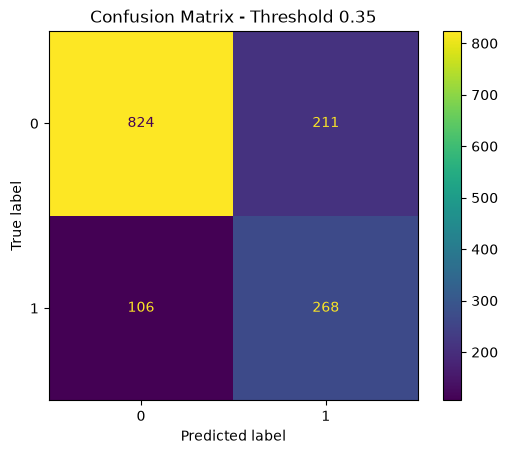

In [37]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_035
)

plt.title("Confusion Matrix - Threshold 0.35")
plt.show()

At the selected threshold of 0.35, the model correctly identifies 268 churn customers, while 106 actual churn customers remain undetected. The lower threshold improves recall compared with the default 0.50 threshold, but this comes at the cost of more false positives, with 211 non-churn customers incorrectly classified as churn. This result reflects the expected precision-recall trade-off.

## Final Findings

Overall, Logistic Regression provides a useful baseline model with good ranking ability, as reflected by ROC-AUC. Lowering the classification threshold from 0.50 to 0.35 improves recall substantially and slightly increases the F1-score, but this comes at the cost of lower precision and more false positives. The model therefore provides a solid reference point for comparison with more flexible classification methods.